In [1]:
import os
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
import cartopy.feature as feature
from cartopy import crs as ccrs


from scipy.signal import welch


In [2]:
eke = xr.open_dataset('../../../Med_Global_EKE/processed_data/GLO/ALL_SAT/NEKE_ALL_SAT_GLO_C3S_vDT2021_19930101_20230607.nc')
mask_med = np.load('../../../Med_Global_EKE/results/masks/2mask_MED_GLO.npy', allow_pickle=True)
eke = eke.where(mask_med)
eke = eke.rename({"EKE": "eke"})

In [3]:
# Open, cut, sort L4
#2mask_MED_MED pour allsatmed
data_path = [
            #  '../../data/med_allsat_L4_008_068/vDT2021/', 
             '../../../Med_Global_EKE/data/glo_allsat_L4_008_047/vDT2021/',
             # '../../data/glo_twosat_L4_008_057/vDT2021/'
            ]
for k in range(len(data_path)):
    listd = os.listdir(data_path[k])
    listd.sort()
    listd = [item for item in listd if not item.startswith(".")]
    dsf = xr.Dataset()
    for year_folder in listd:
        year_path = os.path.join(data_path[k], year_folder)
        file = os.listdir(year_path)
        file = [f for f in file if not f.startswith(".")]
        ds = xr.open_dataset(os.path.join(year_path, file[0]))
        ds = ds[['ugosa', 'vgosa', 'ugos', 'vgos']]
        ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})
        ds['lon'] = xr.where(ds['lon'] > 180, ds['lon'] - 360, ds['lon'])
        dsf = xr.concat([dss for dss in [dsf, ds] if dss], dim='time')
    dsf['time'] = dsf['time'].dt.round("D")
    dsf['lon'] = xr.where(dsf['lon'] > 180, dsf['lon'] - 360, dsf['lon'])
dsf = dsf.where((dsf.lat >= 30) & (dsf.lat <= 47) & 
                       (dsf.lon >= -6) & (dsf.lon <= 37),
                       drop=True)
dsf = dsf.where(mask_med)

In [4]:
data = xr.Dataset({"eke": eke["eke"]}, 
     coords=eke.coords)

data["ugos"] = xr.DataArray(dsf["ugos"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)
data["vgos"] = xr.DataArray(dsf["vgos"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)
data["ugosa"] = xr.DataArray(dsf["ugosa"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)
data["vgosa"] = xr.DataArray(dsf["vgosa"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)

In [5]:
data['ugosa'] = data.ugosa - data.ugosa.mean(dim='time', skipna=False).compute()
data['vgosa'] = data.vgosa - data.vgosa.mean(dim='time', skipna=False).compute()

In [ ]:
data.to_netcdf('../../data/neke_uvgos_a_dt2021.nc')

In [9]:
data = xr.open_dataset('../../data/neke_uvgos_a_dt2021.nc')

In [6]:
def subset_region(ds, lonmin, lonmax, latmin, latmax):
    if ds.lat[0] < ds.lat[-1]:
        lat_slice = slice(latmin, latmax)
    else:
        lat_slice = slice(latmax, latmin)

    return ds.sel(lon=slice(lonmin, lonmax), lat=lat_slice)

In [10]:
lonmin_alb, lonmax_alb, latmin_alb, latmax_alb = -5.4, -1, 35.2, 36.7
lonmin_iera, lonmax_iera, latmin_iera, latmax_iera = 25, 27, 33, 35

# BTR BCR

In [62]:
R = 6371000

lat = data.lat.values
lon = data.lon.values

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

dlat = np.gradient(lat_rad)
dlon = np.gradient(lon_rad)

dx = R * np.cos(lat_rad)[:, None] * dlon
dy = R * dlat[:]

dx = xr.DataArray(dx, coords={"lat": data.lat, "lon": data.lon}, dims=("lat","lon"))
dy = xr.DataArray(dy, coords={"lat": data.lat}, dims=("lat"))
dy = dy.broadcast_like(data.ugos)

In [77]:
# Turbulent momentums
uu = (data.ugosa*data.ugosa)
vv = (data.vgosa*data.vgosa)
uv = (data.ugosa*data.vgosa)
# Mean flows
umean = (data.ugos - data.ugosa).mean(dim='time')
vmean = (data.vgos - data.vgosa).mean(dim='time')
# Compute the derivatives
dudx = umean.differentiate("lon") / dx
dudy = umean.differentiate("lat") / dy
dvdx = vmean.differentiate("lon") / dx
dvdy = vmean.differentiate("lat") / dy
# Compute the BTR
btr_t = -(uu * dudx + uv * (dvdx + dudy) + vv * dvdy)
btr = btr_t.mean(dim='time')

In [83]:
btr_t_alb = subset_region(btr_t, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)

In [84]:
btr_alb = btr_t_alb.mean(('lat', 'lon'))

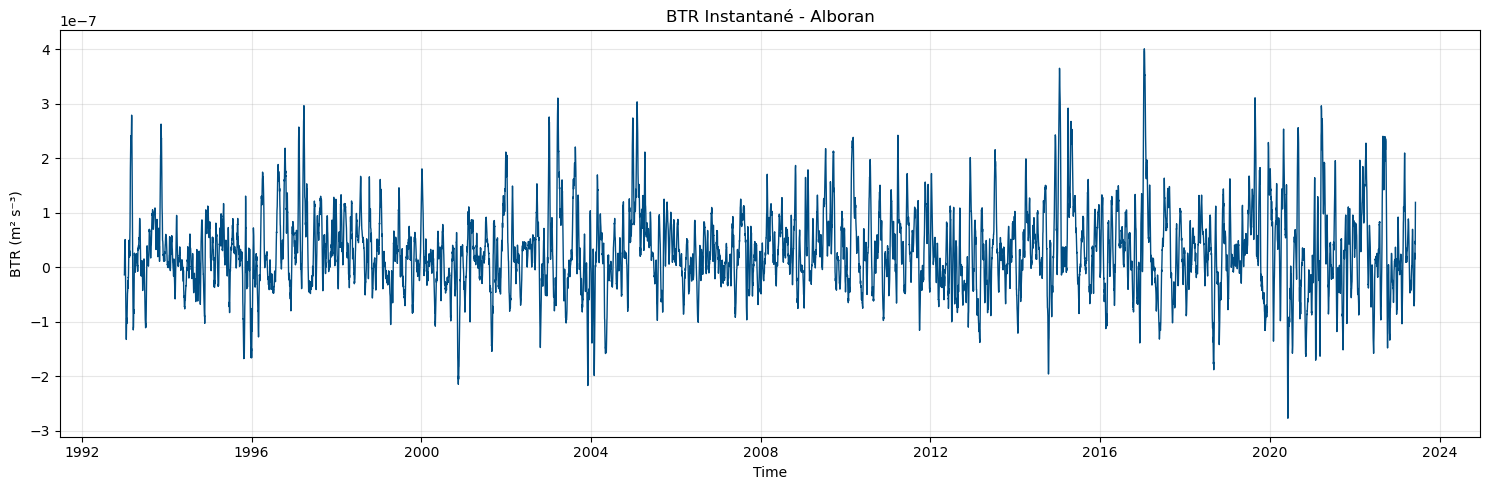

In [88]:

fig, ax = plt.subplots(figsize=(15, 5))

btr_alb.plot(ax=ax, color="#004d83", linewidth=1)

ax.set_title("BTR Instantané - Alboran")
ax.set_ylabel("BTR (m² s⁻³)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


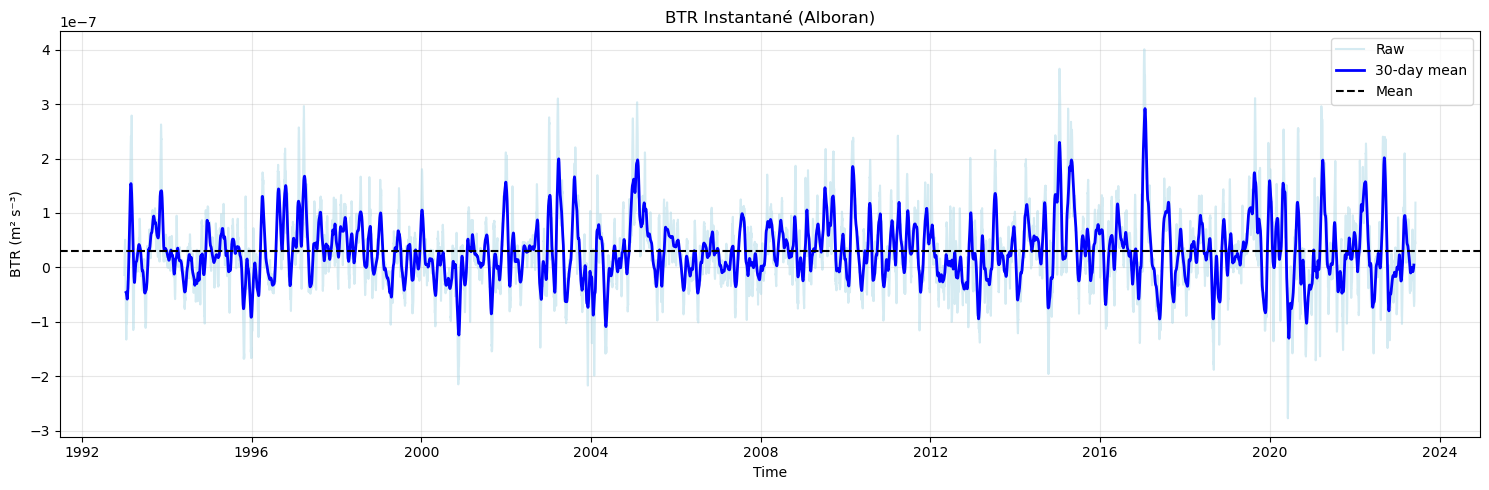

In [91]:
fig, ax = plt.subplots(figsize=(15, 5))

# signal brut
btr_alb.plot(ax=ax, color="lightblue", alpha=0.5, label="Raw")

# lissage (30 jours)
btr_smooth = btr_alb.rolling(time=30, center=True).mean()
btr_smooth.plot(ax=ax, color="blue", linewidth=2, label="30-day mean")

# moyenne globale
ax.axhline(btr_alb.mean(), color="k", linestyle="--", label="Mean")

ax.set_title("BTR Instantané (Alboran)")
ax.set_ylabel("BTR (m² s⁻³)")
ax.grid(True, alpha=0.3)

ax.legend()
plt.tight_layout()
plt.show()

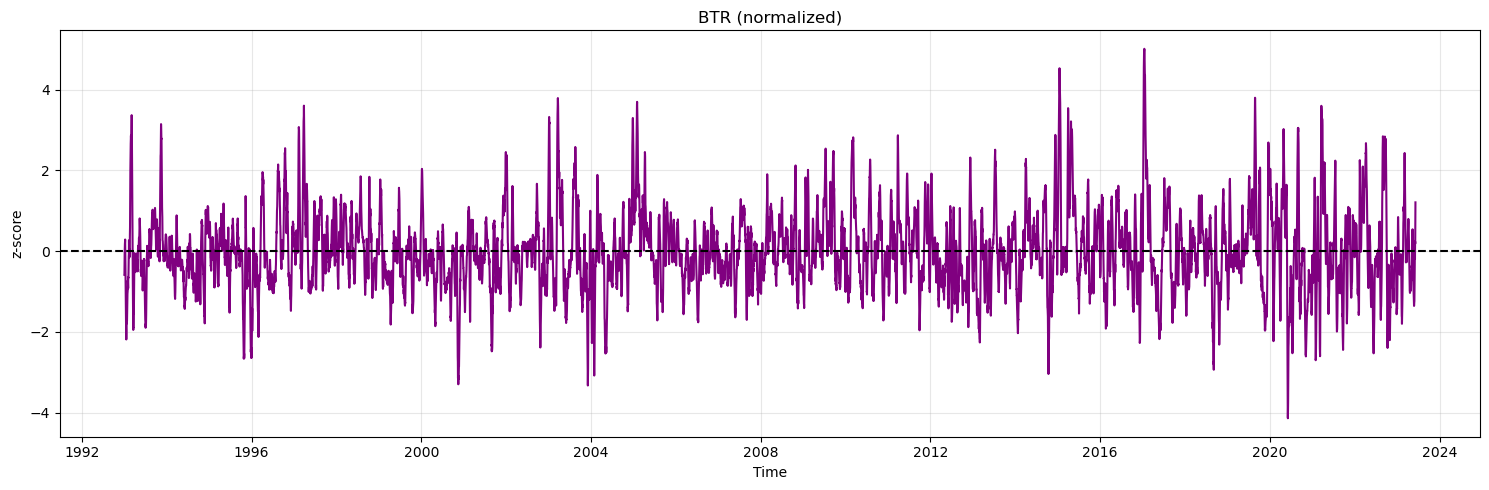

In [95]:
def zscore(x):
    return (x - x.mean()) / x.std()

btr_z = zscore(btr_alb)

fig, ax = plt.subplots(figsize=(15, 5))

btr_z.plot(ax=ax, color="purple", linewidth=1.5)

ax.set_title("BTR (normalized)")
ax.set_ylabel("z-score")
ax.axhline(0, color="k", linestyle="--")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

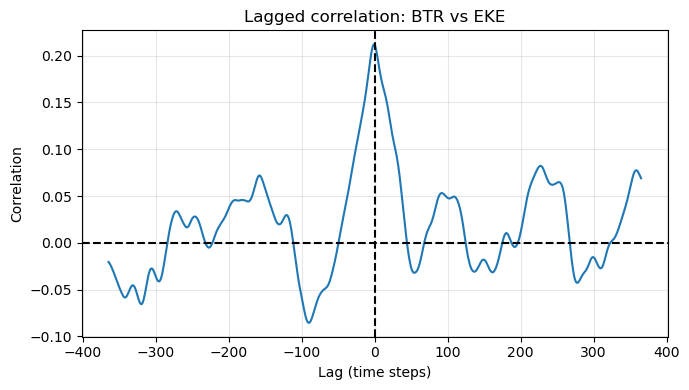

In [106]:
# --- séries temporelles ---
btr = btr_t_alb.mean(("lat","lon"))
eke_alb = subset_region(data.eke, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)
eke = eke_alb.mean(("lat","lon"))

# --- normalisation ---
def zscore(x):
    return (x - x.mean()) / x.std()

btr_z = zscore(btr)
eke_z = zscore(eke)

# --- calcul corrélation avec lag ---
lags = np.arange(-365, 366)  # ±365 jours ou pas de temps

corrs = []

for lag in lags:
    corrs.append(xr.corr(btr_z, eke_z.shift(time=lag)))

corrs = xr.concat(corrs, dim="lag")
corrs["lag"] = lags



fig, ax = plt.subplots(figsize=(7,4))

corrs.plot(ax=ax)

ax.axhline(0, color="k", linestyle="--")
ax.axvline(0, color="k", linestyle="--")

ax.set_xlabel("Lag (time steps)")
ax.set_ylabel("Correlation")
ax.set_title("Lagged correlation: BTR vs EKE")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_990861/1512327621.py:22: RuntimeWarning: divide by zero encountered in divide
  period = 1 / freqs


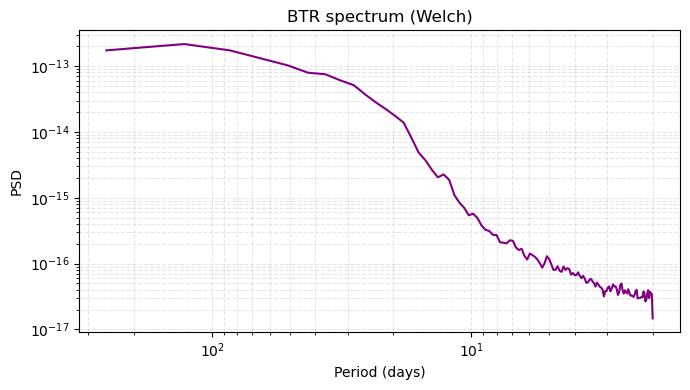

In [107]:

# enlever NaN
btr_clean = btr.fillna(0).values
eke_clean = eke.fillna(0).values

# fréquence d’échantillonnage (IMPORTANT)
# 1 point/jour → fs = 1
fs = 1  

# Welch
freqs, psd = welch(
    btr_clean,
    fs=fs,
    nperseg=256,
    detrend="linear"
)


freqs, psd_eke = welch(eke_clean, fs=fs, nperseg=256)



period = 1 / freqs

fig, ax = plt.subplots(figsize=(7,4))

ax.loglog(period, psd, color="purple")

ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("BTR spectrum (Welch)")

ax.invert_xaxis()  # grandes échelles à gauche ✅

ax.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


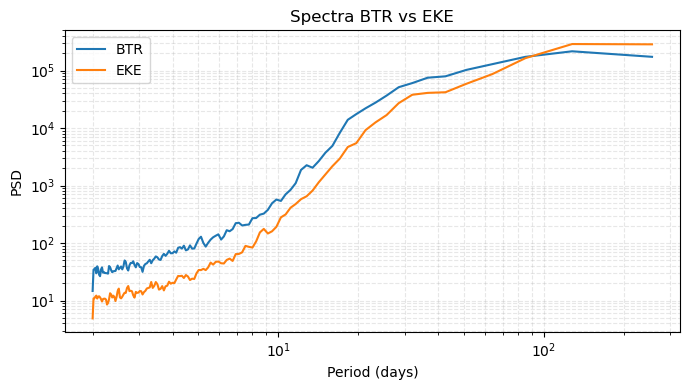

In [122]:
fig, ax = plt.subplots(figsize=(7,4))

ax.loglog(period, psd*1000000000000000000, label="BTR")
ax.loglog(period, psd_eke, label="EKE")

ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("Spectra BTR vs EKE")

ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Wind

In [3]:
wind = xr.open_dataset('../../../Med_Global_EKE/data/era5_wind.nc')
wind = wind.drop_vars(["expver", "number"], errors="ignore").rename({"valid_time": "time", "latitude": "lat", "longitude": "lon"})
wind = wind.sel(time=slice(None, "2023-06-07"))
wind = wind.sortby("lat")
wind = wind.rename({"avg_iews": "surfu", "avg_inss": "surfv"})

In [4]:
R = 6371000

lat = wind.lat.values
lon = wind.lon.values

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

dlat = np.gradient(lat_rad)
dlon = np.gradient(lon_rad)

# dx
dx = R * np.cos(lat_rad)[:, None] * dlon
dx = xr.DataArray(dx, coords={"lat": wind.lat, "lon": wind.lon}, dims=("lat", "lon"))

# dy
dy = xr.DataArray(R * dlat, coords={"lat": wind.lat}, dims=("lat"))
dy = dy.broadcast_like(wind.surfu)

# dérivées
d_tauy_dlon = wind.surfv.differentiate("lon")
d_taux_dlat = wind.surfu.differentiate("lat")

# curl
curl = (d_tauy_dlon / dx) - (d_taux_dlat / dy)

wind["curl"] = curl
wind["curl"].attrs["units"] = "N m^-3"

In [ ]:
wind_alb = subset_region(wind, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)
eke_alb = subset_region(eke, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)

wind_iera = subset_region(wind, lonmin=lonmin_iera, lonmax=lonmax_iera, latmin=latmin_iera, latmax=latmax_iera)
eke_iera = subset_region(eke, lonmin=lonmin_iera, lonmax=lonmax_iera, latmin=latmin_iera, latmax=latmax_iera)


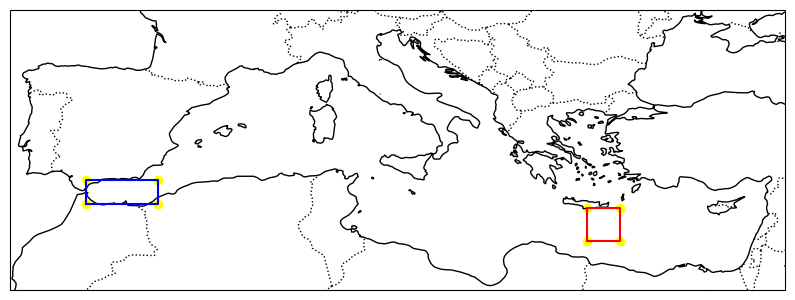

In [28]:
poly_coords = [(lonmin_alb, latmin_alb),(lonmin_alb, latmax_alb), (lonmax_alb, latmax_alb),(lonmax_alb, latmin_alb)]
poly_coords2 = [(lonmin_iera, latmin_iera),(lonmin_iera, latmax_iera), (lonmax_iera, latmax_iera),(lonmax_iera, latmin_iera)]

polygon = Polygon(poly_coords)
polygon2 = Polygon(poly_coords2)

def point_in_polygon(lon, lat):
    return polygon.contains(Point(lon, lat))

def point_in_polygon2(lon, lat):
    return polygon2.contains(Point(lon, lat))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(feature.BORDERS, linestyle=':')
ax.add_feature(feature.COASTLINE)
ax.set_extent([-10, 37, 30, 47], crs=ccrs.PlateCarree())
for lon, lat in poly_coords:
    plt.scatter(lon, lat, color='yellow', transform=ccrs.PlateCarree())
x, y = polygon.exterior.xy
plt.plot(x, y, transform=ccrs.PlateCarree(), color='blue')
for lon, lat in poly_coords2:
    plt.scatter(lon, lat, color='yellow', transform=ccrs.PlateCarree())
x, y = polygon2.exterior.xy
plt.plot(x, y, transform=ccrs.PlateCarree(), color='red')
plt.show()

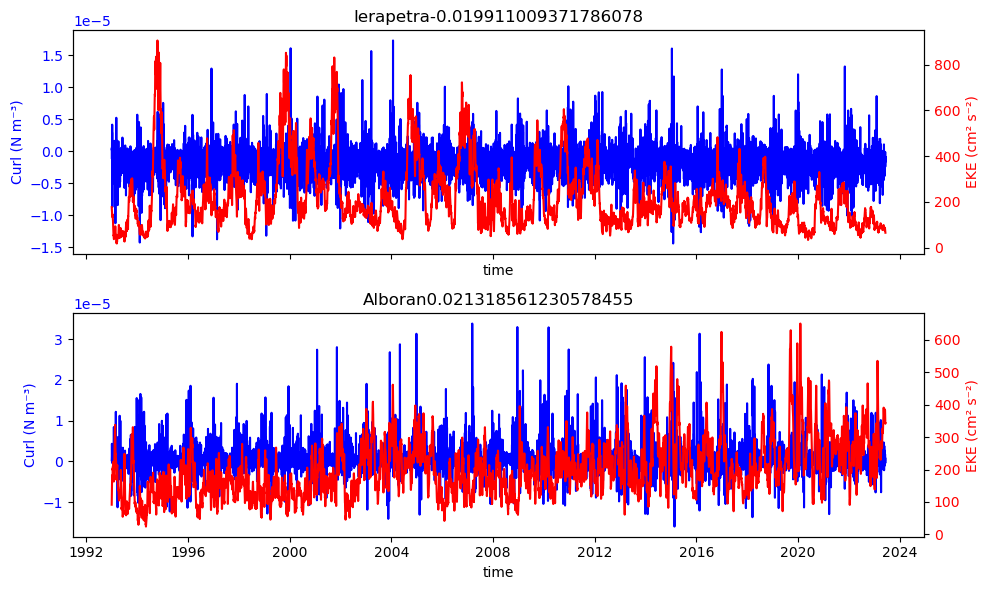

In [31]:
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 🔴 IERAPETRA
# axe 1 (curl)
wind_iera.curl.mean(("lat", "lon")).plot(ax=ax1, color="blue")
ax1.set_ylabel("Curl (N m⁻³)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
# axe 2 (EKE)
ax2 = ax1.twinx()
eke_iera.eke.mean(("lat", "lon")).plot(ax=ax2, color="red")
ax2.set_ylabel("EKE (cm² s⁻²)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_title("Ierapetra" + str(np.corrcoef(wind_iera.curl.mean(("lat", "lon")), eke_iera.eke.mean(("lat", "lon")))[0, 1]))

# 🔵 ALBORAN
# axe 1 (curl)
wind_alb.curl.mean(("lat", "lon")).plot(ax=ax3, color="blue")
ax3.set_ylabel("Curl (N m⁻³)", color="blue")
ax3.tick_params(axis="y", labelcolor="blue")
# axe 2 (EKE)
ax4 = ax3.twinx()
eke_alb.eke.mean(("lat", "lon")).plot(ax=ax4, color="red")
ax4.set_ylabel("EKE (cm² s⁻²)", color="red")
ax4.tick_params(axis="y", labelcolor="red")

ax3.set_title("Alboran" + str(np.corrcoef(wind_alb.curl.mean(("lat", "lon")), eke_alb.eke.mean(("lat", "lon")))[0, 1]))


plt.tight_layout()
plt.show()
